<a href="https://colab.research.google.com/github/Madhan522/SABERNET_Model_Minor_Project/blob/main/SABERNET_minor_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# IMPORTS

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve


In [12]:
#PARAMETERS

IMG_SIZE = (128,128)
BATCH_SIZE = 2
EPOCHS = 10


In [3]:
import os
import json

# 1. Setup Kaggle Credentials
os.environ['KAGGLE_USERNAME'] = "whyyouwantknowmyname"
os.environ['KAGGLE_KEY'] = "47cbe99fb15ed96b4f55163e4b41bcfd"
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

# Download the dataset
dataset_path = api.dataset_download_files('briscdataset/brisc2025', path='.', unzip=True)
print("Files downloaded to:", dataset_path)

In [13]:
# PATHS

train_images_dir = './brisc2025/segmentation_task/train/images'
train_masks_dir  = './brisc2025/segmentation_task/train/masks'

test_images_dir  = './brisc2025/segmentation_task/test/images'
test_masks_dir   = './brisc2025/segmentation_task/test/masks'


In [14]:
# LOAD DATA

def load_data(img_dir, mask_dir):

    images, masks = [], []

    for img, mask in zip(sorted(os.listdir(img_dir)), sorted(os.listdir(mask_dir))):
        i = Image.open(os.path.join(img_dir, img)).convert('L').resize(IMG_SIZE)
        m = Image.open(os.path.join(mask_dir, mask)).resize(IMG_SIZE)

        i = np.array(i)/255.0
        m = (np.array(m)>0).astype(np.float32)

        images.append(i)
        masks.append(m)

    images = np.array(images)[...,np.newaxis]
    masks  = np.array(masks)[...,np.newaxis]

    return images, masks

X, Y = load_data(train_images_dir, train_masks_dir)


In [15]:
# LOSS & METRICS

def dice_coef(y_true, y_pred):
    smooth = 1e-7
    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2.*intersection + smooth)/(tf.reduce_sum(y_true)+tf.reduce_sum(y_pred)+smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def combined_loss(y_true, y_pred):
    return tf.keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)


In [4]:
#  DATASET PATH

train_images_dir = './brisc2025/segmentation_task/train/images'
train_masks_dir  = './brisc2025/segmentation_task/train/masks'

test_images_dir  = './brisc2025/segmentation_task/test/images'
test_masks_dir   = './brisc2025/segmentation_task/test/masks'


In [16]:
# TRANSFORMER BLOCK

def transformer_block(x):
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x,x)
    x = layers.Add()([x,attn])
    x = layers.LayerNormalization()(x)

    ffn = layers.Dense(256,activation='relu')(x)
    ffn = layers.Dense(x.shape[-1])(ffn)

    x = layers.Add()([x,ffn])
    x = layers.LayerNormalization()(x)

    return x


In [20]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve

# SABERNET MODEL

def sabernet():

    inputs = layers.Input((IMG_SIZE[0], IMG_SIZE[1], 1)) # Changed input shape to IMG_SIZE

    c1 = layers.Conv2D(32,3,padding='same',activation='relu')(inputs)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64,3,padding='same',activation='relu')(p1)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(128,3,padding='same',activation='relu')(p2)
    p3 = layers.MaxPooling2D()(c3)

    c4 = layers.Conv2D(256,3,padding='same',activation='relu')(p3)

    x = layers.Reshape((-1,256))(c4)
    x = transformer_block(x)
    x = transformer_block(x)
    x = layers.Reshape((16,16,256))(x) # Adjusted reshape size to 16x16

    u1 = layers.UpSampling2D()(x)
    u1 = layers.concatenate([u1,c3])
    c5 = layers.Conv2D(128,3,padding='same',activation='relu')(u1)

    u2 = layers.UpSampling2D()(c5)
    u2 = layers.concatenate([u2,c2])
    c6 = layers.Conv2D(64,3,padding='same',activation='relu')(u2)

    u3 = layers.UpSampling2D()(c6)
    u3 = layers.concatenate([u3,c1])
    c7 = layers.Conv2D(32,3,padding='same',activation='relu')(u3)

    outputs = layers.Conv2D(1,1,activation='sigmoid')(c7)

    return models.Model(inputs,outputs)

In [21]:
# K-FOLD CROSS VALIDATION

print("\n--- K-FOLD CROSS VALIDATION ---")

kf = KFold(n_splits=3, shuffle=True, random_state=42)
fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):

    print(f"\nFold {fold+1}")

    X_train_k, X_val_k = X[train_idx], X[val_idx]
    Y_train_k, Y_val_k = Y[train_idx], Y[val_idx]

    model_k = sabernet()
    model_k.compile(optimizer='adam', loss=combined_loss, metrics=['accuracy', dice_coef])

    model_k.fit(X_train_k, Y_train_k, epochs=3, batch_size=2, verbose=0)

    _, acc, _ = model_k.evaluate(X_val_k, Y_val_k, verbose=0)

    print("Accuracy:", acc)
    fold_accuracies.append(acc)

print("\nK-Fold Accuracies:", fold_accuracies)
print("Average K-Fold Accuracy:", np.mean(fold_accuracies))



--- K-FOLD CROSS VALIDATION ---

Fold 1
Accuracy: 0.9811971783638

Fold 2
Accuracy: 0.9789533615112305

Fold 3
Accuracy: 0.9864036440849304

K-Fold Accuracies: [0.9811971783638, 0.9789533615112305, 0.9864036440849304]
Average K-Fold Accuracy: 0.9821847279866537


In [22]:
# FINAL TRAINING

X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2)

model = sabernet()
model.compile(optimizer='adam', loss=combined_loss, metrics=['accuracy', dice_coef])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop]
)


Epoch 1/10
1573/1573 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - accuracy: 0.9683 - dice_coef: 0.1865 - loss: 0.9237 - val_accuracy: 0.9717 - val_dice_coef: 0.3289 - val_loss: 0.7731
Epoch 2/10
1573/1573 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9778 - dice_coef: 0.3721 - loss: 0.7223 - val_accuracy: 0.9802 - val_dice_coef: 0.4455 - val_loss: 0.6373
Epoch 3/10
1573/1573 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9837 - dice_coef: 0.4969 - loss: 0.5815 - val_accuracy: 0.9832 - val_dice_coef: 0.5477 - val_loss: 0.5339
Epoch 4/10
1573/1573 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9857 - dice_coef: 0.5517 - loss: 0.5206 - val_accuracy: 0.9868 - val_dice_coef: 0.5761 - val_loss: 0.4868
Epoch 5/10
1573/1573 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9867 - dice_coef: 0.5834 - loss: 0.4841 - val_accuracy: 0.9882 - val_dice_coef: 0.6205 - val_loss: 0.4429
Epoch 6/10
1573/1573 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.9872 - dice_coef: 0.5978 - loss: 0.4680 - val_accu

In [23]:
# TEST

X_test, Y_test = load_data(test_images_dir, test_masks_dir)

pred = model.predict(X_test)
pred = (pred > 0.5).astype(np.uint8)

27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step


In [25]:

# METRICS


y_true = Y_test.flatten()
y_pred = pred.flatten()

print("\nTest Accuracy:", accuracy_score(y_true, y_pred))

def iou(y_true, y_pred):
    inter = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    return np.sum(inter) / (np.sum(union) + 1e-7)

print("IoU:", iou(Y_test, pred))

# FIXED Dice
Y_test_f = tf.cast(Y_test, tf.float32)
pred_f   = tf.cast(pred, tf.float32)

print("Dice:", dice_coef(Y_test_f, pred_f).numpy())


Test Accuracy: 0.9877352692360102
IoU: 0.5313355119528845
Dice: 0.6939505


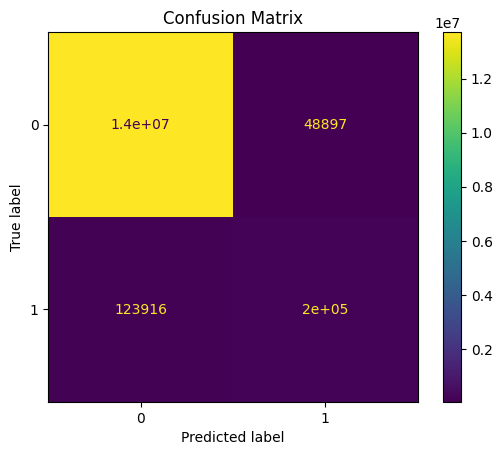

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


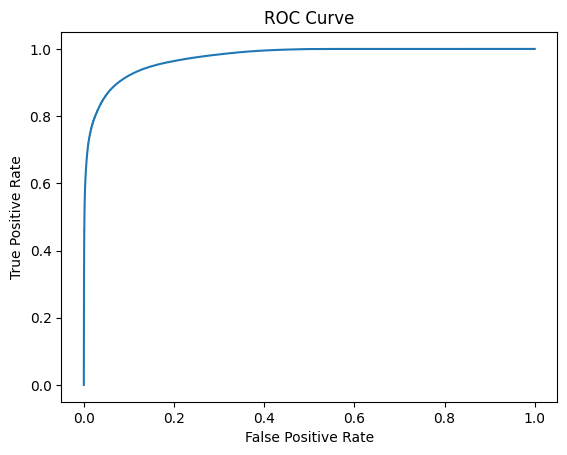

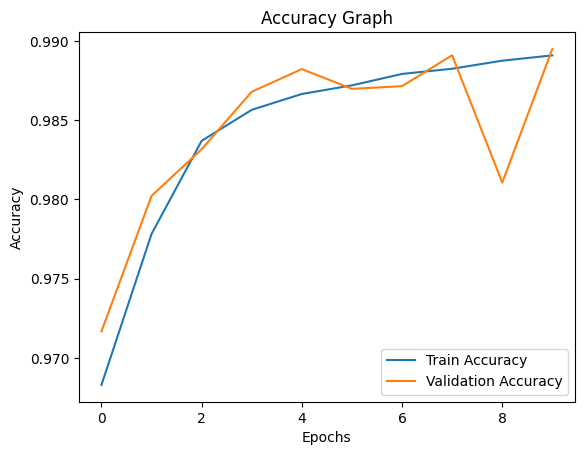

In [26]:

# CONFUSION MATRIX

y_true = Y_test.flatten()
y_pred = pred.flatten()

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()


# ROC CURVE

# use probabilities (not thresholded mask)
y_prob = model.predict(X_test).flatten()

fpr, tpr, _ = roc_curve(y_true, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# ACCURACY GRAPH

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Graph")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


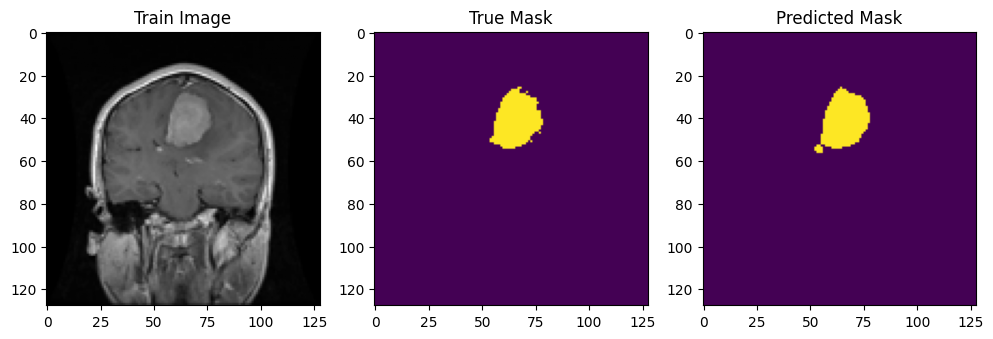

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


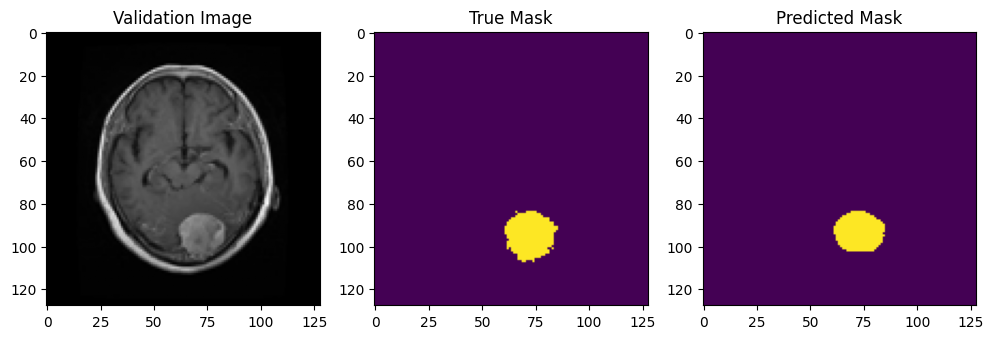

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


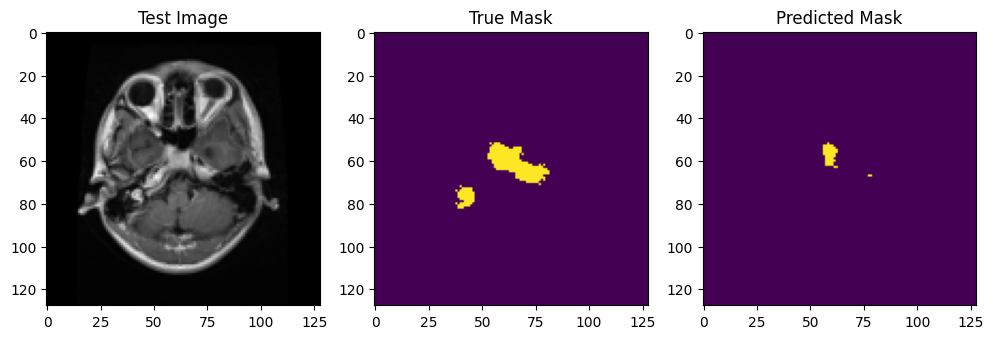

In [31]:
# VISUALIZATION

def show_prediction(X_data, Y_data, title, index=0):

    pred = model.predict(X_data[index:index+1])
    pred_mask = (pred[0] > 0.5).astype(np.uint8).squeeze()

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title(title+" Image")
    plt.imshow(X_data[index].squeeze(), cmap='gray')

    plt.subplot(1,3,2)
    plt.title("True Mask")
    plt.imshow(Y_data[index].squeeze())

    plt.subplot(1,3,3)
    plt.title("Predicted Mask")
    plt.imshow(pred_mask)

    plt.show()

show_prediction(X_train, Y_train, "Train", 3)
show_prediction(X_val, Y_val, "Validation", 4)
show_prediction(X_test, Y_test, "Test", 3)